# [SOLUTIONS] Lab 2 — Neural Architecture Search HW-aware on HW-NAS-Bench

## Search space, estimation strategy, and simple search algorithms

In this lab, we will work with a tabular benchmark: a CSV file extracted from [HW-NAS-Bench](https://openreview.net/pdf?id=_0kaDkv3dVf$0), which contains, for each architecture in the [NAS-Bench-201](https://openreview.net/forum?id=HJxyZkBKDr$0) search space, the accuracy obtained after training and several hardware metrics (latency, energy, ...) measured on different devices.

Having a tabular benchmark means that "training and evaluating" a network costs a table lookup: we can therefore compare search algorithms in a few seconds, repeating experiments across many seeds, which would be impossible if we had to actually train every network.

Lab objectives

1. Extend the search to the hardware-aware case (latency constraints, Pareto front).
2. (Bonus) Take a first look at evolutionary algorithms and Reinforcement Learning.


## 0. Setup

In [ ]:
import itertools
import time
import warnings
import os
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

if not os.path.exists("utils.py"):
    REPO_URL = "https://raw.githubusercontent.com/bizzarriA/NAS-lab/main"
    urllib.request.urlretrieve(f"{REPO_URL}/utils.py", "utils.py")

from utils import OPS, EDGES, load_HW_benchmark, draw_cell, Oracle, make_gp, plot_regret

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1. Data loading



The benchmark is downloaded automatically. `load_benchmark` returns a table with **one row per architecture** (15625 in total) and always the same columns, whatever dataset and device you choose:

| column | meaning |
| --- | --- |
| `arch_str` | architecture string in NAS-Bench-201 format |
| `op_e1_0` … `op_e3_2` | operation on each edge (`op_eJ_I` = edge from node I to node J) |
| `ops` | the same 6 operations as a tuple, handy for the search algorithms |
| `acc` | **validation** accuracy (%) after 200 epochs: this is what we optimize |
| `test_acc` | test accuracy (%): use it only to report the final result |
| `lat`, `energy` | latency (ms) and energy (mJ) on the chosen device |
| `cost` | training time (s), used to simulate the search cost |
| `flops`, `params` | FLOPs (M) and parameters (M) |

You can change `DATASET` and `DEVICE`. Not all devices provide every metric: energy is available only for `edgegpu`, `eyeriss` and `fpga` (otherwise the column is empty).

In [ ]:
DATA_PATH = f"hw_nasbench201.csv.gz"   # or a local path
if not os.path.exists(DATA_PATH):
    urllib.request.urlretrieve(f"{REPO_URL}/{DATA_PATH}", f"{DATA_PATH}")

DATASET = "cifar100"   # cifar10 | cifar100 | imagenet16
DEVICE = "edgegpu"   # ["edgegpu", "raspi4", "edgetpu", "pixel3", "eyeriss", "fpga"]


df = load_HW_benchmark(DATA_PATH, dataset=DATASET, device=DEVICE)

N_ARCH = len(df)
ARCH2IDX = {ops: i for i, ops in enumerate(df["ops"])}   # tuple of ops -> row index
BEST_ACC = df["acc"].max()                               # best accuracy in the whole space
df.head()

Loaded 15625 architectures | dataset = cifar100 | device = edgegpu


,arch_str,op_e1_0,op_e2_0,op_e2_1,op_e3_0,op_e3_1,op_e3_2,ops,acc,test_acc,lat,energy,cost,flops,params
0,|avg_pool_3x3~0|+|nor_conv_1x1~0|skip_connect~...,avg_pool_3x3,nor_conv_1x1,skip_connect,nor_conv_1x1,skip_connect,skip_connect,"(avg_pool_3x3, nor_conv_1x1, skip_connect, nor...",52.7000,52.9133,5.8661,24.4713,2888.4372,15.6532,0.1352
1,|nor_conv_3x3~0|+|nor_conv_3x3~0|avg_pool_3x3~...,nor_conv_3x3,nor_conv_3x3,avg_pool_3x3,skip_connect,nor_conv_3x3,skip_connect,"(nor_conv_3x3, nor_conv_3x3, avg_pool_3x3, ski...",69.8267,70.2933,6.4954,28.7637,4339.2828,113.9572,0.8083
2,|avg_pool_3x3~0|+|nor_conv_3x3~0|nor_conv_3x3~...,avg_pool_3x3,nor_conv_3x3,nor_conv_3x3,avg_pool_3x3,avg_pool_3x3,avg_pool_3x3,"(avg_pool_3x3, nor_conv_3x3, nor_conv_3x3, avg...",54.3000,54.8667,6.5679,29.3388,4534.3554,78.5678,0.5652
3,|avg_pool_3x3~0|+|skip_connect~0|none~1|+|none...,avg_pool_3x3,skip_connect,none,none,none,skip_connect,"(avg_pool_3x3, skip_connect, none, none, none,...",57.4133,58.3067,2.4131,10.3138,1666.0980,7.7889,0.0792
4,|skip_connect~0|+|skip_connect~0|nor_conv_1x1~...,skip_connect,skip_connect,nor_conv_1x1,skip_connect,skip_connect,nor_conv_1x1,"(skip_connect, skip_connect, nor_conv_1x1, ski...",59.5667,60.1400,4.5549,19.4676,2593.7196,15.6532,0.1352


## 2. Benchmark exploration



Before searching, let's look at the data: how are the accuracies distributed? How much does an accurate network cost (in latency)?

             acc   test_acc        lat     energy       cost      flops  \
count  15625.000  15625.000  15625.000  15625.000  15625.000  15625.000   
mean      61.300     61.406      5.065     22.904   3655.974     54.975   
std       12.142     12.172      1.533      7.090    943.338     33.918   
min        1.000      1.000      0.506      2.045   1084.462      7.789   
25%       59.060     59.240      4.148     18.637   2978.400     19.585   
50%       65.167     65.287      5.329     24.034   3634.250     47.110   
75%       67.740     67.880      6.156     27.898   4317.074     82.500   
max       73.493     73.513     11.464     43.550   6921.663    220.126   

          params  
count  15625.000  
mean       0.404  
std        0.233  
min        0.079  
25%        0.163  
50%        0.350  
75%        0.593  
max        1.537  


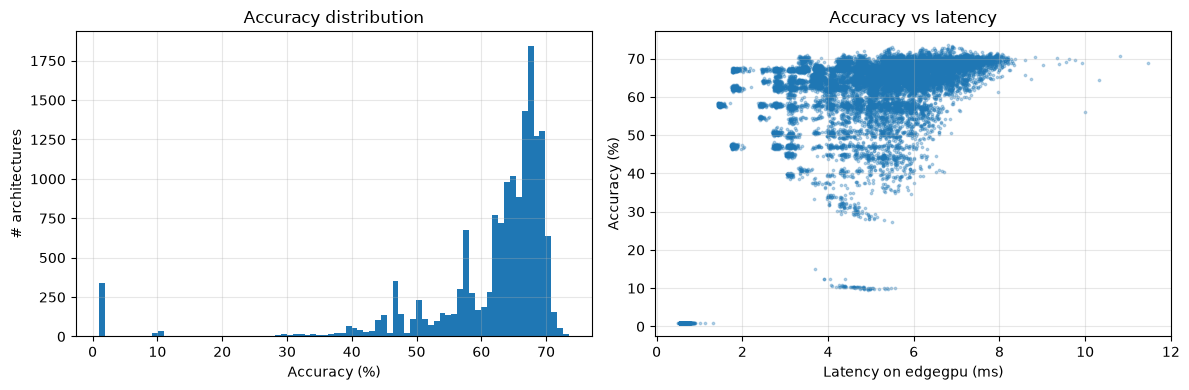

Best architecture: |nor_conv_3x3~0|+|nor_conv_3x3~0|nor_conv_3x3~1|+|skip_connect~0|nor_conv_3x3~1|nor_conv_3x3~2| → 73.49%
99th percentile of accuracy: 71.03


In [3]:
print(df[["acc", "test_acc", "lat", "energy", "cost", "flops", "params"]].describe().round(3))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(df["acc"], bins=80, color="tab:blue")
ax[0].set(xlabel="Accuracy (%)", ylabel="# architectures", title="Accuracy distribution")
ax[1].scatter(df["lat"], df["acc"], s=3, alpha=0.3)
ax[1].set(xlabel=f"Latency on {DEVICE} (ms)", ylabel="Accuracy (%)", title="Accuracy vs latency")
plt.tight_layout(); plt.show()

best = df.loc[df["acc"].idxmax()]
print("Best architecture:", best["arch_str"], f"→ {best['acc']:.2f}%")
print("99th percentile of accuracy:", np.percentile(df["acc"], 99).round(2))

## 3. The search space: cell-based design



In NAS-Bench-201, the network consists of a fixed skeleton (stem, 3 stages of stacked cells, reduction blocks between stages, classifier). Search concerns only the cell, which is then repeated.

The cell is a DAG with 4 nodes (0 = input, 3 = output). Each pair of nodes $i<j$ is connected by an edge, for a total of 6 edges, and on each edge one operation is chosen from:

| operation | meaning |
| --- | --- |
| `none` | absent edge (zero) |
| `skip_connect` | identity |
| `nor_conv_1x1` | ReLU-Conv1x1-BN |
| `nor_conv_3x3` | ReLU-Conv3x3-BN |
| `avg_pool_3x3` | 3x3 average pooling |

Each node sums the contributions of incoming edges.

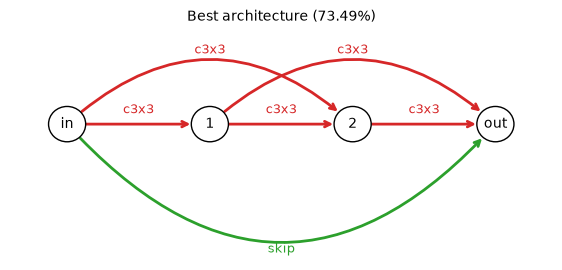

<Axes: title={'center': 'Best architecture (73.49%)'}>

In [4]:
draw_cell(best, title=f"Best architecture ({best['acc']:.2f}%)")

In [5]:
o = Oracle(df, budget=3)
print(o.query(0), o.query(1), o.query(0), "| queries used:", o.n_queries)   # re-query is free
print("Best so far:", o.best())

52.7 69.8267 52.7 | queries used: 2
Best so far: (('nor_conv_3x3', 'nor_conv_3x3', 'avg_pool_3x3', 'skip_connect', 'nor_conv_3x3', 'skip_connect'), 69.8267)


## 4. Search algorithms from Lab 1



The hardware-aware searches below reuse the building blocks implemented in Lab 1: the one-hot encoding, Expected Improvement, Random Search, Bayesian Optimization and the multi-seed comparison. They are collected in the next cell without changes, so that this notebook can run on its own.

Unconstrained baselines computed in 45s


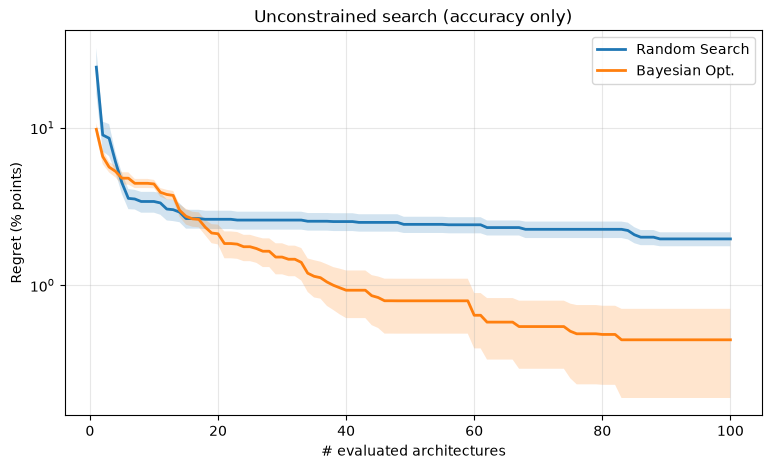

In [6]:
BUDGET = 100
N_RUNS = 10


def encode_onehot(ops):
    v = np.zeros(len(EDGES) * len(OPS))
    for e, op in enumerate(ops):
        v[e * len(OPS) + OPS.index(op)] = 1.0
    return v

X_ALL = np.stack(df["ops"].map(encode_onehot).to_numpy())


def expected_improvement(mu, sigma, best_f, xi=0.01):
    sigma = np.maximum(sigma, 1e-12)
    imp = mu - best_f - xi
    z = imp / sigma
    ei = imp * norm.cdf(z) + sigma * norm.pdf(z)
    return np.where(sigma > 1e-9, ei, 0.0)


def random_search(oracle, seed=0):
    rng = np.random.default_rng(seed)
    for idx in rng.permutation(N_ARCH):
        if oracle.remaining() <= 0:
            break
        oracle.query(idx)
    return oracle


def bayesian_optimization(oracle, n_init=10, xi=0.01, seed=0):
    rng = np.random.default_rng(seed)
    observed = list(rng.choice(N_ARCH, size=n_init, replace=False))
    y = [oracle.query(i) for i in observed]
    while oracle.remaining() > 0:
        gp = make_gp(seed)
        gp.fit(X_ALL[observed], np.array(y))
        mask = np.ones(N_ARCH, dtype=bool)
        mask[observed] = False
        cand = np.flatnonzero(mask)
        mu, sigma = gp.predict(X_ALL[cand], return_std=True)
        nxt = int(cand[np.argmax(expected_improvement(mu, sigma, max(y), xi))])
        observed.append(nxt)
        y.append(oracle.query(nxt))
    return oracle


def run_many(algo, n_runs=N_RUNS, budget=BUDGET, **kw):
    curves = []
    for s in range(n_runs):
        c = algo(Oracle(df, budget, seed=s), seed=s, **kw).incumbent_curve()
        curves.append(BEST_ACC - np.pad(c, (0, budget - len(c)), mode="edge"))
    return np.array(curves)


t0 = time.time()
results = {"Random Search": run_many(random_search),
           "Bayesian Opt.": run_many(bayesian_optimization)}
print(f"Unconstrained baselines computed in {time.time() - t0:.0f}s")
plot_regret(results, "Unconstrained search (accuracy only)")

## 5. Hardware-aware NAS



This is where we depart from the previous lab: we no longer care about accuracy alone, but also about latency on the target device. In particular, we want to find the architectures that are Pareto-optimal, that is, those with high accuracy and low latency at the same time.

An architecture $a$ dominates an architecture $b$ if it is at least as accurate and at least as fast, and strictly better in one of the two. The Pareto front is the set of non-dominated architectures: moving along it, any gain in accuracy must be paid with extra latency.

Note: in this setting measuring latency is much cheaper than training the network, so we can assume we know it for free for every architecture, before evaluating its accuracy.

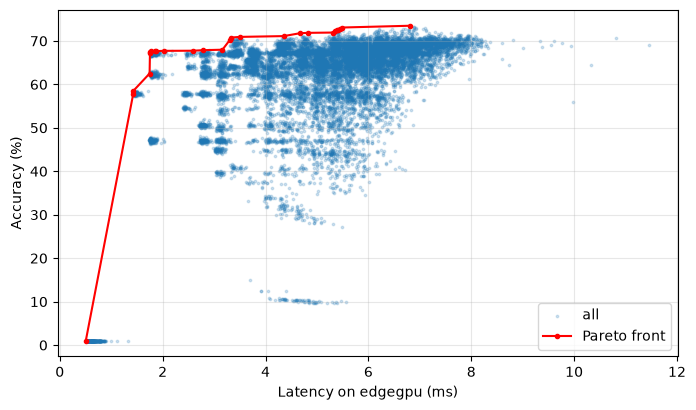

Architectures on the front: 26


In [7]:
def pareto_front(acc, lat):
    # Indices of the non-dominated architectures (high accuracy, low latency)
    order = np.argsort(lat)
    front, best = [], -np.inf
    for i in order:
        if acc[i] > best:
            front.append(i); best = acc[i]
    return np.array(front)

if df["lat"].notna().any():
    pf = pareto_front(df["acc"].to_numpy(), df["lat"].to_numpy())
    plt.scatter(df["lat"], df["acc"], s=3, alpha=0.2, label="all")
    plt.plot(df["lat"].iloc[pf], df["acc"].iloc[pf], "r.-", label="Pareto front")
    plt.xlabel(f"Latency on {DEVICE} (ms)"); plt.ylabel("Accuracy (%)"); plt.legend(); plt.show()
    print(f"Architectures on the front: {len(pf)}")
else:
    print("No latency column for this dataset/device: section not available.")

### EXERCISE 6 — Search under a latency constraint

We choose the median latency as the constraint. Modify Random Search and BO so that they only evaluate feasible architectures (latency ≤ `LAT_MAX`). Compare the regret with respect to the best feasible architecture.

Hint: it is enough to restrict the set of candidates.

In [8]:
LAT_MAX = df["lat"].median()
FEASIBLE = np.flatnonzero(df["lat"].to_numpy() <= LAT_MAX)
BEST_FEAS = df["acc"].iloc[FEASIBLE].max()
print(f"Constraint: latency ≤ {LAT_MAX:.3f} ms  | feasible: {len(FEASIBLE)}  | best feasible: {BEST_FEAS:.2f}%")


def random_search_constrained(oracle, seed=0):
    rng = np.random.default_rng(seed)
    for idx in rng.permutation(FEASIBLE):
        if oracle.remaining() <= 0:
            break
        oracle.query(idx)
    return oracle


def bo_constrained(oracle, n_init=10, xi=0.01, seed=0):
    rng = np.random.default_rng(seed)
    observed = list(rng.choice(FEASIBLE, size=n_init, replace=False))
    y = [oracle.query(i) for i in observed]
    feas_mask = np.zeros(N_ARCH, dtype=bool); feas_mask[FEASIBLE] = True
    while oracle.remaining() > 0:
        gp = make_gp(seed); gp.fit(X_ALL[observed], np.array(y))
        mask = feas_mask.copy(); mask[observed] = False
        cand = np.flatnonzero(mask)
        mu, sigma = gp.predict(X_ALL[cand], return_std=True)
        nxt = int(cand[np.argmax(expected_improvement(mu, sigma, max(y), xi))])
        observed.append(nxt); y.append(oracle.query(nxt))
    return oracle

Constraint: latency ≤ 5.329 ms  | feasible: 7813  | best feasible: 71.93%


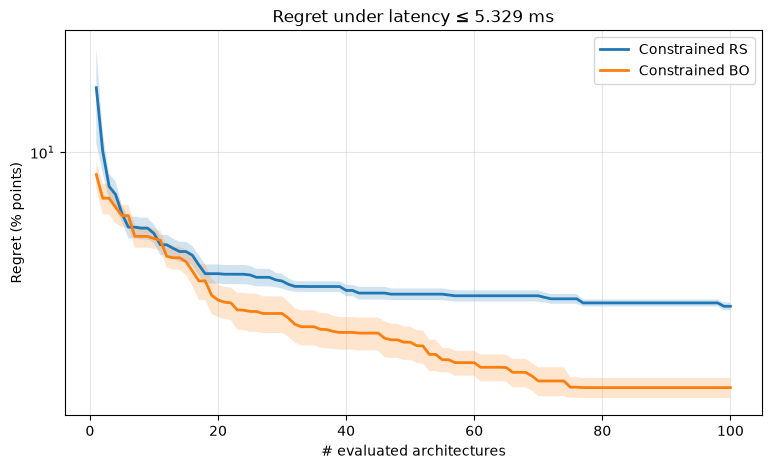

Best overall: 73.49%  | best feasible: 71.93%  | accuracy lost to the constraint: 1.57 points


In [9]:
res_c = {"Constrained RS": run_many(random_search_constrained),
         "Constrained BO": run_many(bo_constrained)}
plot_regret(res_c, f"Regret under latency ≤ {LAT_MAX:.3f} ms")

print(f"Best overall: {BEST_ACC:.2f}%  | best feasible: {BEST_FEAS:.2f}%  "
      f"| accuracy lost to the constraint: {BEST_ACC - BEST_FEAS:.2f} points")

#### Questions — Hardware-aware NAS
1. Is the best architecture overall feasible? How much accuracy is lost by imposing the constraint?
2. An alternative to the hard constraint is a scalarized objective function, for example $\mathrm{acc}(x) - \lambda\,\mathrm{lat}(x)$ (MnasNet uses a multiplicative form of this idea). What are the pros and cons compared to the constraint?
3. (Optional) Repeat with the latency of another device available in the CSV. Do the optimal architectures change? What does this tell us about transferability across devices?

### BONUS EXERCISE — Checking the latency a posteriori



In Exercise 6 we assumed that the latency of every architecture is known in advance, so we could filter the search space before starting. Now we drop this assumption: the latency of an architecture is known only after it has been picked by the search algorithm and measured on the device.

The search therefore works as follows: pick an architecture, measure its latency and

- if it satisfies the constraint (latency ≤ `LAT_MAX`), train it and keep it as a candidate;
- otherwise discard it without training it.

Every picked architecture costs one query of the budget, whether it is kept or not, because measuring the latency on the device is not free. However, a discarded architecture is never trained, so it does not add to the total (simulated) training time.

`LatencyCheckOracle` implements this cost model. `oracle.query(idx)` returns the accuracy of a feasible architecture or `None` for a discarded one, and in both cases it stores the measured latency in `oracle.measured_lat`. Discarded architectures are recorded in the history with accuracy 0, so the regret stays at its maximum until the first feasible architecture is found.

Implement:

1. `random_search_check`: Random Search over the whole space, with the latency checked after each pick.
2. `bo_check`: Bayesian Optimization that learns the constraint while searching. Fit a GP on the accuracy of the kept architectures and a second GP on the latency of all the picked architectures, and use as acquisition function the Expected Improvement multiplied by the probability of being feasible, $P(\mathrm{lat} \le \mathrm{LAT\_MAX}) = \Phi\left(\frac{\mathrm{LAT\_MAX} - \mu_{lat}}{\sigma_{lat}}\right)$.

Then compare them with the pre-filtered versions of Exercise 6, both in terms of regret and of total training time.

<details>
<summary>Hint</summary>

Keep in `observed` all the picked architectures (kept and discarded): their latency is known, so they are all useful for the latency GP, and none of them should be picked again. Only the kept ones, those with `oracle.cache[i] is not None`, go into the accuracy GP. As long as fewer than two architectures have been kept, use the probability of being feasible alone as acquisition function.
</details>

In [10]:
from utils import LatencyCheckOracle


o = LatencyCheckOracle(df, budget=5, lat_max=LAT_MAX)
print([o.query(i) for i in range(5)], "| rejected:", o.n_rejected, "| training time:", round(o.sim_cost, 1), "s")

[None, None, None, np.float64(57.4133), np.float64(59.5667)] | rejected: 3 | training time: 4259.8 s


In [11]:
def random_search_check(oracle, seed=0):
    rng = np.random.default_rng(seed)
    for idx in rng.permutation(N_ARCH):
        if oracle.remaining() <= 0:
            break
        oracle.query(idx)
    return oracle


def bo_check(oracle, n_init=10, xi=0.01, seed=0):
    rng = np.random.default_rng(seed)
    observed = list(rng.choice(N_ARCH, size=n_init, replace=False))
    for i in observed:
        oracle.query(i)
    while oracle.remaining() > 0:
        obs = np.array(observed)
        lat_obs = np.array([oracle.measured_lat[i] for i in obs])
        kept = np.array([oracle.cache[i] is not None for i in obs])

        mask = np.ones(N_ARCH, dtype=bool); mask[obs] = False
        cand = np.flatnonzero(mask)

        # Surrogate for the latency, trained on every picked architecture
        gp_lat = make_gp(seed); gp_lat.fit(X_ALL[obs], lat_obs)
        mu_l, sd_l = gp_lat.predict(X_ALL[cand], return_std=True)
        p_feas = norm.cdf((LAT_MAX - mu_l) / np.maximum(sd_l, 1e-9))

        if kept.sum() >= 2:
            # Surrogate for the accuracy, trained on the kept architectures only
            acc_kept = np.array([oracle.cache[i] for i in obs[kept]])
            gp_acc = make_gp(seed); gp_acc.fit(X_ALL[obs[kept]], acc_kept)
            mu, sigma = gp_acc.predict(X_ALL[cand], return_std=True)
            acq = expected_improvement(mu, sigma, acc_kept.max(), xi) * p_feas
        else:
            acq = p_feas
        nxt = int(cand[np.argmax(acq)])
        observed.append(nxt); oracle.query(nxt)
    return oracle

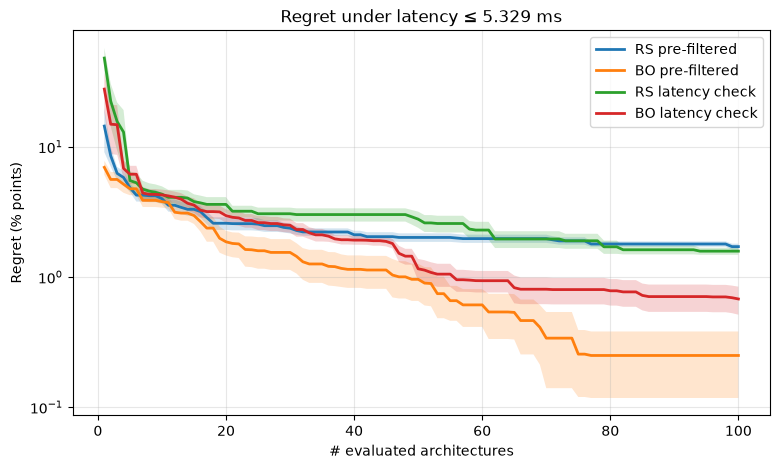

                  final regret (mean)  training time (h, mean)  \
RS pre-filtered                  1.71                    85.14   
BO pre-filtered                  0.25                   108.73   
RS latency check                 1.58                    43.48   
BO latency check                 0.68                    70.25   

                  rejected archs (mean)  
RS pre-filtered                     0.0  
BO pre-filtered                     0.0  
RS latency check                   49.4  
BO latency check                   34.3  


In [12]:
def run_many_check(algo, make_oracle, n_runs=N_RUNS):
    curves, train_time, rejected = [], [], []
    for s in range(n_runs):
        o = algo(make_oracle(s), seed=s)
        c = o.incumbent_curve()
        curves.append(BEST_FEAS - np.pad(c, (0, BUDGET - len(c)), mode="edge"))
        train_time.append(o.sim_cost)
        rejected.append(getattr(o, "n_rejected", 0))
    return np.array(curves), np.array(train_time), np.array(rejected)


prefiltered = lambda s: Oracle(df, BUDGET, seed=s)
checked = lambda s: LatencyCheckOracle(df, BUDGET, LAT_MAX, seed=s)
runs = {"RS pre-filtered": run_many_check(random_search_constrained, prefiltered),
        "BO pre-filtered": run_many_check(bo_constrained, prefiltered),
        "RS latency check": run_many_check(random_search_check, checked),
        "BO latency check": run_many_check(bo_check, checked)}

plot_regret({k: v[0] for k, v in runs.items()}, f"Regret under latency ≤ {LAT_MAX:.3f} ms")
print(pd.DataFrame({k: {"final regret (mean)": c[:, -1].mean(),
                        "training time (h, mean)": t.mean() / 3600,
                        "rejected archs (mean)": r.mean()}
                    for k, (c, t, r) in runs.items()}).T.round(2))

#### Questions — Latency checked a posteriori
1. How much budget does Random Search waste on discarded architectures? Relate it to the fraction of feasible architectures in the space.
2. Does BO learn to avoid infeasible architectures? How does the number of rejected architectures evolve during the search?
3. Compare the total training time of the four methods. When is a budget counted in queries a good proxy of the real search cost, and when is it not?
4. How would the picture change with a tighter constraint, for example the 10th percentile of the latency?

## 6. Co-exploration



So far the device was fixed and we only searched over architectures. Now we also want to find the best hardware for a given accuracy constraint. In other words, we want to explore the architecture space and the device space jointly. For simplicity, we consider only 3 devices: `edgegpu`, `eyeriss` and `fpga`. At each step, the search algorithm must therefore choose an architecture and a device.

Formally, with $a$ an architecture and $d$ a device:

$$\min_{(a,\,d)} \ \mathrm{lat}(a, d) \quad \text{s.t.} \quad \mathrm{acc}(a) \ge \mathrm{ACC\_MIN}$$

Accuracy depends only on the architecture, while latency depends on both. The joint search space contains $15625 \times 3 = 46875$ (architecture, device) pairs, and each evaluation of a pair counts as one query (training the network and deploying it on the device).

To reuse the `Oracle`, we turn the constrained problem into a single score to maximize: $-\mathrm{lat}(a,d)$ for feasible pairs, and minus the worst latency in the table for infeasible pairs, so that any feasible pair is better than any infeasible one. The regret is then the extra latency (ms) of the best pair found with respect to the optimal pair.

Accuracy constraint: acc ≥ 69.96%  | feasible architectures: 784 / 15625
                                                  arch_str    acc    lat  \
device                                                                     
fpga     |nor_conv_3x3~0|+|none~0|skip_connect~1|+|skip...  70.06  2.906   
edgegpu  |nor_conv_3x3~0|+|skip_connect~0|nor_conv_3x3~...  70.16  3.302   
eyeriss  |nor_conv_3x3~0|+|none~0|skip_connect~1|+|skip...  70.06  3.403   

         energy  
device           
fpga     20.340  
edgegpu  15.606  
eyeriss   0.692  

Optimal pair: fpga, latency 2.906 ms


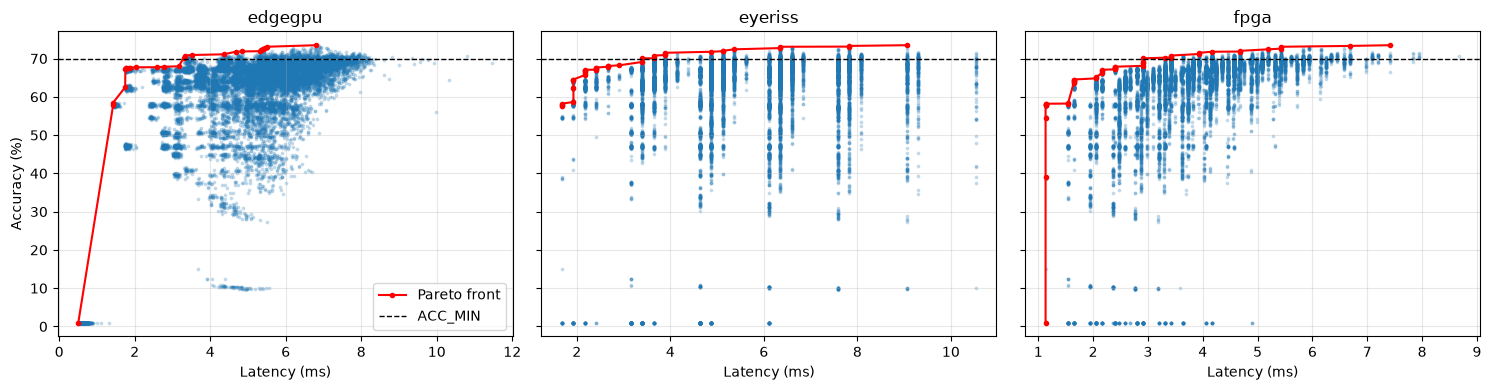

In [13]:
# Devices among which the co-exploration can choose (the three with both latency and energy)
CO_DEVICES = ["edgegpu", "eyeriss", "fpga"]

# Accuracy constraint: the 95th percentile of the validation accuracy,
# i.e. only the top 5% of the architectures are accurate enough.
# Using a percentile instead of a fixed number keeps the constraint meaningful for every DATASET.
ACC_MIN = np.percentile(df["acc"], 95)

# df_co: the joint search space, one row per (architecture, device) pair.
# It is built by stacking one copy of the benchmark per device (N_ARCH rows each), with an
# extra column "device". The accuracy is the same in every copy, while "lat" and "energy"
# are those measured on that device. Since the architecture order is the same in every block,
# row r of df_co is architecture r % N_ARCH (row of df) on device CO_DEVICES[r // N_ARCH].
df_co = pd.concat([load_HW_benchmark(DATA_URL, dataset=DATASET, device=d, verbose=False).assign(device=d)
                   for d in CO_DEVICES], ignore_index=True)
# Sanity check: every block lists the architectures in the same order as df
assert (df_co["arch_str"].to_numpy().reshape(len(CO_DEVICES), -1) == df["arch_str"].to_numpy()).all()

N_CO = len(df_co)                     # size of the joint space: N_ARCH * len(CO_DEVICES) pairs
CO_ARCH = np.arange(N_CO) % N_ARCH    # CO_ARCH[r]: index (row of df / X_ALL) of the architecture of pair r
CO_DEV = np.arange(N_CO) // N_ARCH    # CO_DEV[r]: index in CO_DEVICES of the device of pair r
CO_FEAS = df_co["acc"].to_numpy() >= ACC_MIN   # CO_FEAS[r]: True if pair r satisfies the accuracy constraint
LAT_WORST = df_co["lat"].max()        # highest latency in the whole joint space

# "score": the single quantity maximized by the Oracle.
#   feasible pair   -> -latency (maximizing -lat = minimizing lat)
#   infeasible pair -> -LAT_WORST, which is lower than the score of any feasible pair
df_co["score"] = np.where(CO_FEAS, -df_co["lat"], -LAT_WORST)
BEST_SCORE = df_co["score"].max()     # score of the optimal pair = -(lowest feasible latency)

print(f"Accuracy constraint: acc ≥ {ACC_MIN:.2f}%  | feasible architectures: {CO_FEAS[:N_ARCH].sum()} / {N_ARCH}")

# Ground truth from an exhaustive search: the fastest feasible architecture on each device
best_per_dev = (df_co[CO_FEAS].sort_values("lat").groupby("device").head(1)
                .set_index("device")[["arch_str", "acc", "lat", "energy"]].round(3))
print(best_per_dev)
print(f"\nOptimal pair: {best_per_dev['lat'].idxmin()}, latency {-BEST_SCORE:.3f} ms")

# One plot per device: all architectures, Pareto front and accuracy constraint
fig, ax = plt.subplots(1, len(CO_DEVICES), figsize=(15, 4), sharey=True)
for k, d in enumerate(CO_DEVICES):
    sub = df_co[df_co["device"] == d]                                    # the N_ARCH rows of device d
    pf = pareto_front(sub["acc"].to_numpy(), sub["lat"].to_numpy())     # positions (in sub) of the front
    ax[k].scatter(sub["lat"], sub["acc"], s=3, alpha=0.2)
    ax[k].plot(sub["lat"].iloc[pf], sub["acc"].iloc[pf], "r.-", label="Pareto front")
    ax[k].axhline(ACC_MIN, color="k", ls="--", lw=1, label="ACC_MIN")   # feasible pairs lie above this line
    ax[k].set(xlabel="Latency (ms)", title=d)
ax[0].set_ylabel("Accuracy (%)"); ax[0].legend(loc="lower right")
plt.tight_layout(); plt.show()

### EXERCISE 7 — Joint search over architectures and devices

Implement two co-exploration algorithms that, at each step, choose a row of `df_co`, that is, an (architecture, device) pair:

1. `random_search_co`: Random Search on the joint space.
2. `bo_co`: constrained Bayesian Optimization. Use two surrogate models:
   - a GP for the accuracy, trained on the one-hot encoding of the architecture only (`X_ALL`);
   - a GP for the latency, trained on the encoding of the architecture concatenated with a one-hot encoding of the device (`X_CO`, 30 + 3 dimensions).

   The acquisition function is the constrained Expected Improvement: the EI of $-\mathrm{lat}$ with respect to the best feasible latency observed so far, multiplied by the probability that the pair is feasible, $P(\mathrm{acc} \ge \mathrm{ACC\_MIN}) = 1 - \Phi\left(\frac{\mathrm{ACC\_MIN} - \mu_{acc}}{\sigma_{acc}}\right)$. As long as no feasible pair has been observed, use the probability of feasibility alone.

Both functions accept a `devices` argument: the list of devices the search is allowed to use. With a single device we obtain the classic approach where the hardware is fixed first and only the architecture is searched, which we use as a baseline.

Hint: since accuracy does not depend on the device, the accuracy GP can be evaluated once on `X_ALL` and its predictions mapped to the rows of `df_co` with `CO_ARCH`.

In [14]:
# X_CO: encoding of every pair of df_co for the latency GP, shape (N_CO, 30 + 3).
# The first 30 columns are the one-hot encoding of the architecture (the same rows of X_ALL),
# the last 3 columns are the one-hot encoding of the device.
X_CO = np.hstack([X_ALL[CO_ARCH], np.eye(len(CO_DEVICES))[CO_DEV]])


def allowed_rows(devices):
    # Indices of the rows of df_co whose device is in `devices`
    return np.flatnonzero(np.isin(df_co["device"].to_numpy(), devices))


def random_search_co(oracle, devices=CO_DEVICES, seed=0):
    # oracle:  Oracle built on df_co with metric="score"
    # devices: devices the search may use (all of them = co-exploration, one = fixed hardware)
    rng = np.random.default_rng(seed)
    # A random permutation of the allowed pairs = uniform sampling without replacement
    for idx in rng.permutation(allowed_rows(devices)):
        if oracle.remaining() <= 0:
            break
        oracle.query(idx)
    return oracle


def bo_co(oracle, devices=CO_DEVICES, n_init=10, xi=0.01, seed=0):
    # oracle:  Oracle built on df_co with metric="score"
    # devices: devices the search may use (all of them = co-exploration, one = fixed hardware)
    # n_init:  number of random pairs evaluated before using the surrogate models
    # xi:      exploration parameter of the Expected Improvement
    rng = np.random.default_rng(seed)

    # allowed[r] is True if pair r is on one of the allowed devices
    allowed = np.zeros(N_CO, dtype=bool); allowed[allowed_rows(devices)] = True

    # observed: indices (rows of df_co) of the pairs evaluated so far, in query order
    observed = list(rng.choice(np.flatnonzero(allowed), size=n_init, replace=False))
    for i in observed:
        oracle.query(i)

    # The oracle returns only the score, but evaluating a pair means training the network
    # and running it on the device, so both its accuracy and its latency become known.
    # These arrays cover every pair: the algorithm reads them only at the observed indices.
    acc_all = df_co["acc"].to_numpy()
    lat_all = df_co["lat"].to_numpy()

    while oracle.remaining() > 0:
        obs = np.array(observed)

        # Surrogate for the accuracy: inputs are architectures only (X_ALL, 30 dims),
        # because the accuracy does not depend on the device
        gp_acc = make_gp(seed); gp_acc.fit(X_ALL[CO_ARCH[obs]], acc_all[obs])
        # Surrogate for the latency: inputs are architecture + device (X_CO, 33 dims)
        gp_lat = make_gp(seed); gp_lat.fit(X_CO[obs], lat_all[obs])

        # cand: allowed pairs not evaluated yet
        mask = allowed.copy(); mask[obs] = False
        cand = np.flatnonzero(mask)

        # Accuracy prediction: computed once per architecture on X_ALL (N_ARCH rows),
        # then mapped to the candidate pairs through CO_ARCH (same prediction on every device)
        mu_a, sd_a = gp_acc.predict(X_ALL, return_std=True)
        mu_a, sd_a = mu_a[CO_ARCH[cand]], np.maximum(sd_a[CO_ARCH[cand]], 1e-9)
        # p_feas: probability, according to the GP, that the candidate satisfies acc >= ACC_MIN
        p_feas = 1 - norm.cdf((ACC_MIN - mu_a) / sd_a)

        # feas_obs: which observed pairs satisfy the accuracy constraint
        feas_obs = acc_all[obs] >= ACC_MIN
        if feas_obs.any():
            # Latency prediction (mean and standard deviation) for every candidate pair
            mu_l, sd_l = gp_lat.predict(X_CO[cand], return_std=True)
            # Incumbent: best (= lowest) latency among the feasible pairs, as -lat to maximize
            best_neg_lat = -lat_all[obs][feas_obs].min()
            # Constrained EI: improvement on -latency, weighted by the probability of being feasible
            acq = expected_improvement(-mu_l, sd_l, best_neg_lat, xi) * p_feas
        else:
            # No feasible pair seen yet: there is no incumbent, so just look for a feasible one
            acq = p_feas

        # np.argmax gives a position inside cand: cand[...] converts it to a row of df_co
        nxt = int(cand[np.argmax(acq)])
        observed.append(nxt); oracle.query(nxt)
    return oracle


def run_many_co(algo, n_runs=N_RUNS, **kw):
    # Runs `algo` with n_runs seeds and returns the regret curves, shape (n_runs, BUDGET).
    # Regret = BEST_SCORE - best score found = extra latency (ms) w.r.t. the optimal pair.
    # Before the first feasible pair it equals LAT_WORST - lat_opt (the maximum regret).
    out = []
    for s in range(n_runs):
        c = algo(Oracle(df_co, BUDGET, metric="score", seed=s), seed=s, **kw).incumbent_curve()
        # pad: if the algorithm stopped early, repeat its last value up to BUDGET
        out.append(BEST_SCORE - np.pad(c, (0, BUDGET - len(c)), mode="edge"))
    return np.array(out)

We now compare the co-exploration algorithms with the approach that fixes the device first and then searches only the architecture (constrained BO on a single device). BO on the joint space requires two GP fits per iteration: with the settings below the cell takes a few minutes.

Done in 187s


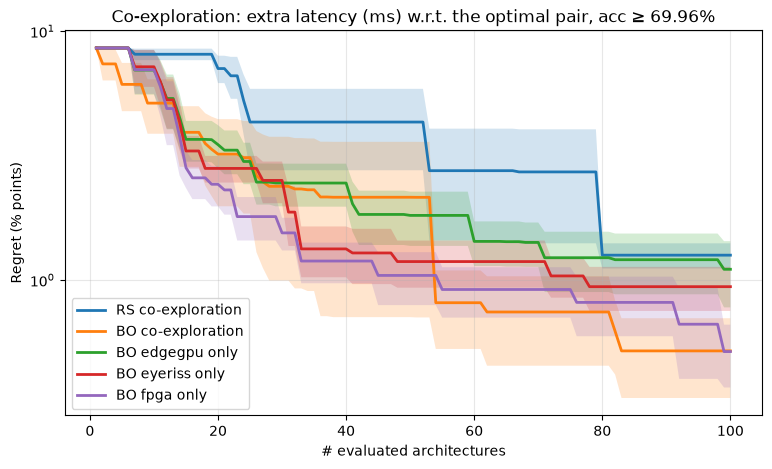

                   final regret (ms, mean)    std
RS co-exploration                    1.258  0.326
BO co-exploration                    0.518  0.410
BO edgegpu only                      1.104  0.734
BO eyeriss only                      0.939  0.423
BO fpga only                         0.515  0.326


In [15]:
N_RUNS_CO = 5   # fewer seeds than in the previous sections: each BO run fits two GPs per iteration
t0 = time.time()

# res_co: method name -> regret curves (N_RUNS_CO x BUDGET)
res_co = {"RS co-exploration": run_many_co(random_search_co, n_runs=N_RUNS_CO),
          "BO co-exploration": run_many_co(bo_co, n_runs=N_RUNS_CO)}
# Baselines: the device is fixed first and only the architecture is searched
for d in CO_DEVICES:
    res_co[f"BO {d} only"] = run_many_co(bo_co, n_runs=N_RUNS_CO, devices=[d])
print(f"Done in {time.time() - t0:.0f}s")

plot_regret(res_co, f"Co-exploration: extra latency (ms) w.r.t. the optimal pair, acc ≥ {ACC_MIN:.2f}%")
# Final regret (after BUDGET queries): mean and standard deviation over the seeds
print(pd.DataFrame({k: {"final regret (ms, mean)": v[:, -1].mean(), "std": v[:, -1].std()}
                    for k, v in res_co.items()}).T.round(3))

Queries per device: {'edgegpu': np.int64(11), 'eyeriss': np.int64(3), 'fpga': np.int64(86)}
Best pair found: fpga, |nor_conv_3x3~0|+|avg_pool_3x3~0|none~1|+|skip_connect~0|nor_conv_1x1~1|none~2|, acc 70.24%, latency 3.315 ms


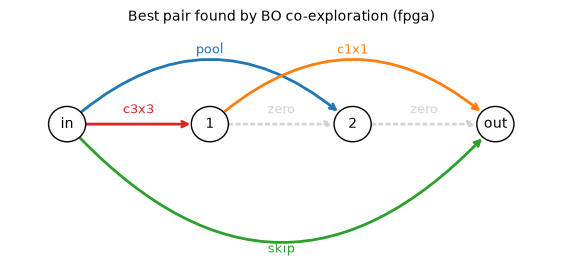

In [16]:
# Which device does the joint search end up choosing? A single run of BO co-exploration (seed 0)
o = bo_co(Oracle(df_co, BUDGET, metric="score", seed=0), seed=0)

# queried: rows of df_co evaluated by the search, in query order
queried = np.array([i for i, _ in o.history])
# How the budget was split among the devices
print("Queries per device:", dict(zip(*np.unique(df_co["device"].iloc[queried], return_counts=True))))

# i_best: the evaluated pair with the highest score (the fastest feasible one)
i_best = queried[np.argmax(df_co["score"].to_numpy()[queried])]
print(f"Best pair found: {df_co['device'].iat[i_best]}, {df_co['arch_str'].iat[i_best]}, "
      f"acc {df_co['acc'].iat[i_best]:.2f}%, latency {df_co['lat'].iat[i_best]:.3f} ms")
draw_cell(df_co.iloc[i_best], title=f"Best pair found by BO co-exploration ({df_co['device'].iat[i_best]})");

### Questions — Co-exploration
1. Which device gives the lowest latency under the accuracy constraint? Does the answer change if you relax or tighten `ACC_MIN` (for example the 80th or the 99th percentile)?
2. Is the best architecture the same on all three devices? Why can fixing the hardware first lead to a suboptimal design, even when the architecture search on that device is perfect?
3. How are the queries of BO co-exploration distributed among the devices? Is the exploration of a device that turns out to be worse wasted budget?
4. Here the hardware space contains only 3 points and evaluating a pair costs the same on every device. In real co-exploration, the hardware is described by design parameters (number of processing elements, buffer sizes, dataflow, ...) and simulating or synthesizing it can be expensive. How would you adapt the search?

## Bonus — Uno sguardo ad altri algoritmi

### Algoritmi evolutivi: *Regularized Evolution* (Real et al., 2019)

Si mantiene una **popolazione** di architetture. A ogni passo:
1. si estrae un **campione** casuale di `S` individui dalla popolazione (*tournament selection*);
2. il migliore del campione diventa **genitore** e viene **mutato** (si cambia l'operazione su un arco a caso);
3. il figlio viene valutato e inserito; l'individuo **più vecchio** viene rimosso (*aging*: questa è la "regolarizzazione").

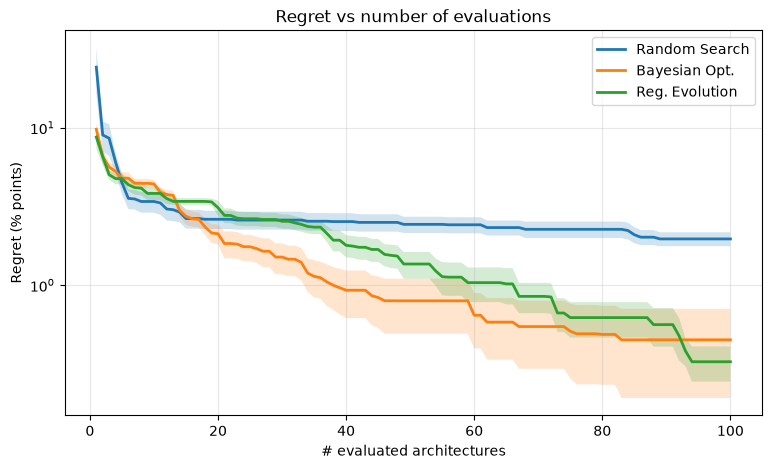

In [17]:
from collections import deque

def mutate(ops, rng):
    ops = list(ops)
    e = rng.integers(6)
    ops[e] = rng.choice([o for o in OPS if o != ops[e]])
    return tuple(ops)


def regularized_evolution(oracle, pop_size=20, sample_size=5, seed=0):
    rng = np.random.default_rng(seed)
    population = deque()
    for idx in rng.choice(N_ARCH, size=pop_size, replace=False):
        population.append((df["ops"].iat[idx], oracle.query(idx)))
    while oracle.remaining() > 0:
        sample = [population[i] for i in rng.choice(len(population), sample_size, replace=False)]
        parent = max(sample, key=lambda t: t[1])[0]
        child = mutate(parent, rng)
        while ARCH2IDX[child] in oracle.cache and oracle.remaining() > 0:
            child = mutate(child, rng)   # evitiamo di "sprecare" mutazioni già viste
        population.append((child, oracle.query_ops(child)))
        population.popleft()
    return oracle


results["Reg. Evolution"] = run_many(regularized_evolution)
plot_regret(results)

### Reinforcement Learning (Zoph & Le, 2017) — versione minimale

Un **controller** definisce una distribuzione sulle architetture; qui, per semplicità, è una distribuzione categorica indipendente per ciascun arco, con logit $\theta_{e,o}$ (nel lavoro originale è una RNN). Si campiona un'architettura, la si valuta, e si aggiornano i logit con **REINFORCE**:
$$
\theta \leftarrow \theta + \eta\,(R - b)\,\nabla_\theta \log p_\theta(\text{arch})
$$
dove $R$ è l'accuratezza e $b$ una baseline (media mobile) che riduce la varianza.

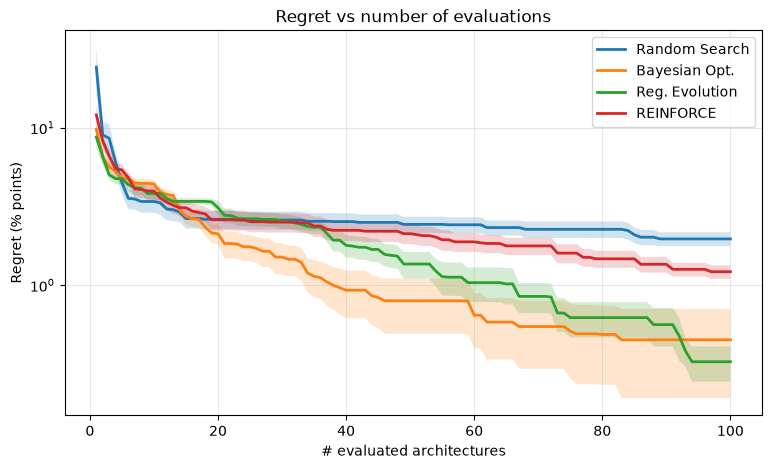

In [18]:
def reinforce_search(oracle, lr=0.1, baseline_decay=0.9, seed=0):
    rng = np.random.default_rng(seed)
    theta = np.zeros((6, len(OPS)))
    baseline = None
    while oracle.remaining() > 0:
        p = np.exp(theta - theta.max(1, keepdims=True)); p /= p.sum(1, keepdims=True)
        choice = [rng.choice(len(OPS), p=p[e]) for e in range(6)]
        ops = tuple(OPS[c] for c in choice)
        R = oracle.query_ops(ops)
        baseline = R if baseline is None else baseline_decay * baseline + (1 - baseline_decay) * R
        adv = (R - baseline) / 10.0           # scala del reward (punti %)
        for e, c in enumerate(choice):        # grad log-softmax = onehot - p
            grad = -p[e]; grad[c] += 1
            theta[e] += lr * adv * grad
    return oracle

results["REINFORCE"] = run_many(reinforce_search)
plot_regret(results)